# Error Analysis
Run `src/error_analysis.py` first, then load the failure-case CSV here.

In [5]:
!cd .. && python src/error_analysis.py --predictions results/logreg_tfidf_10k_test_predictions.csv --model logreg_tfidf_10k

     true_label_name    n  accuracy  mean_overlap
0      contradiction   32  0.218750      0.077240
1         entailment   25  0.320000      0.089986
2    neutral_related  317  0.621451      0.063103
3  neutral_unrelated  626  0.563898      0.044834


In [6]:
import pandas as pd
from pathlib import Path
root = Path('..')
failures = sorted((root/'results').glob('*top_failure_cases.csv'))
failures

[PosixPath('../results/logreg_tfidf_10k_top_failure_cases.csv')]

In [7]:
if failures:
    df = pd.read_csv(failures[0])
    display(df[['sentence1','sentence2','true_label_name','pred_label_name','overlap']].head(10))

,sentence1,sentence2,true_label_name,pred_label_name,overlap
0,"Similar, logaritmii cu diferite baze constante...",Exponențialele cu baze diferite nu sunt de ace...,entailment,neutral_related,0.307692
1,Un semispațiu închis poate fi exprimat ca o in...,Un ''politop convex închis'' poate fi privit c...,neutral_unrelated,contradiction,0.220339
2,Drepturile contelui au fost din ce în ce mai m...,Vechile comitate s-au divizat din ce în ce mai...,neutral_related,entailment,0.218750
3,Pilar este o locuitoare a orașului Macondo car...,"Ea devine mama fiilor lor, aureliano josé și a...",neutral_related,neutral_unrelated,0.190476
4,Nici un candidat nu a obținut o majoritate în ...,A fost organizat un al doilea tur de scrutin ș...,neutral_related,neutral_unrelated,0.189189
5,Modul se poate deplasa pe toată lungimea vârfu...,Planul focal este separat față de planul de ex...,neutral_related,entailment,0.186047
6,"Prenumele lui Lee, Jun-fan a fost scris la înc...",Caracterul chinez ''jun'' din numele lui lee a...,neutral_related,neutral_unrelated,0.181818
7,Kościuszko a concluzionat că Napoleon a creat ...,Kościuszko nu s-a mutat în ducatul varșoviei ș...,neutral_related,entailment,0.166667
8,"În următoarele alegeri, din 1963 și 1967 a fos...",A fost candidatul natural pentru postul de pre...,neutral_related,neutral_unrelated,0.166667
9,Dacă nu autoritățile sunt cele care să decidă ...,Dacă monarhul e numit de dumnezeu să fie în fr...,entailment,neutral_related,0.163265


## Error Analysis Interpretation

The failure cases show that the TF-IDF logistic regression model often struggles when the two sentences share some topical or lexical similarity but the logical relationship is more subtle. Several examples are true neutral cases but are predicted as entailment, suggesting that the model sometimes treats related content as logical implication.
The model also confuses neutral-unrelated and neutral-related. This makes sense because TF-IDF mainly represents word overlap and word frequency, but it does not deeply model sentence meaning, discourse context, or logical structure.
Some entailment examples are predicted as neutral, which suggests that the model can recognize that two sentences are related, but it cannot always determine whether one sentence actually follows from the other.

In [9]:
confusions = (
    df.groupby(["true_label_name", "pred_label_name"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

confusions

,true_label_name,pred_label_name,count
6,neutral_unrelated,neutral_related,10
4,neutral_related,neutral_unrelated,8
3,neutral_related,entailment,4
1,entailment,neutral_related,3
0,contradiction,neutral_related,2
5,neutral_unrelated,contradiction,2
2,neutral_related,contradiction,1


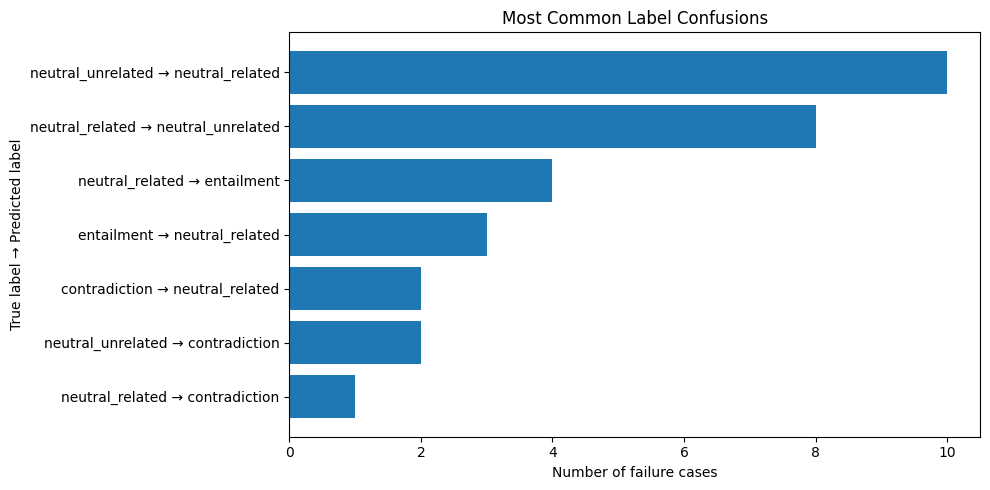

In [10]:
import matplotlib.pyplot as plt

top_confusions = confusions.head(8)
labels = top_confusions["true_label_name"] + " → " + top_confusions["pred_label_name"]

plt.figure(figsize=(10, 5))
plt.barh(labels, top_confusions["count"])
plt.xlabel("Number of failure cases")
plt.ylabel("True label → Predicted label")
plt.title("Most Common Label Confusions")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Error Analysis Summary

The most common failure type is confusion between neutral_unrelated and neutral_related. The model predicted neutral_related for 10 true neutral_unrelated examples, and predicted neutral_unrelated for 8 true neutral_related examples. This suggests that the TF-IDF logistic regression model can often identify that examples are not clear entailments or contradictions, but struggles to decide whether the two sentences are topically related.
The next most common error is neutral_related → entailment, with 4 cases. This shows that when two sentences share vocabulary or topic, the model may overestimate the logical connection and treat relatedness as entailment.
There are also some entailment → neutral_related errors, meaning the model sometimes recognizes sentence similarity but fails to determine that one sentence actually follows from the other.